In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [ ]:
!unzip -q "/content/diabetic_data.csv.zip" -d "/content/extracted"

In [ ]:
df = pd.read_csv('/content/extracted/diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [ ]:
df = df.drop([
    'encounter_id',
    'patient_nbr',
    'weight',
    'payer_code',
    'medical_specialty',
    'diag_1',
    'diag_2',
    'diag_3'
], axis=1)

In [ ]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df = df.drop(['max_glu_serum', 'A1Cresult'], axis=1)

In [ ]:
df = df.replace('?', np.nan)
df = df.dropna()

# encode
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])
# target values
df['readmitted'] = df['readmitted'].replace({
    '<30': 2,
    '>30': 1,
    'NO': 0
})

In [ ]:
X = df.drop('readmitted', axis=1)
y = df['readmitted']

In [ ]:
X.dtypes

,0
race,int64
gender,int64
age,int64
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64
num_lab_procedures,int64
num_procedures,int64
num_medications,int64


In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
df.isnull().sum()

,0
race,0
gender,0
age,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **SMOTE**

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

# **Random forest**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# Define evaluation function here so this cell is self-contained
def evaluate_model(y_test, y_pred, name):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred,
          target_names=['Non-Diabetic','Pre-Diabetic','Diabetic']))
    print(confusion_matrix(y_test, y_pred))

# Tuned Random Forest
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_tuned.fit(X_train, y_train)
rf_tuned_pred = rf_tuned.predict(X_test)
evaluate_model(y_test, rf_tuned_pred, "Random Forest (Tuned)")


  Random Forest (Tuned)
Accuracy: 0.5768129051711142
              precision    recall  f1-score   support

Non-Diabetic       0.32      0.06      0.10      2175
Pre-Diabetic       0.50      0.40      0.44      7058
    Diabetic       0.62      0.80      0.70     10666

    accuracy                           0.58     19899
   macro avg       0.48      0.42      0.41     19899
weighted avg       0.54      0.58      0.54     19899

[[ 135  850 1190]
 [ 168 2821 4069]
 [ 121 2023 8522]]


# **Gradient Boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

# **AdaBoost**

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ab = AdaBoostClassifier()
ab.fit(X_train, y_train)

ab_pred = ab.predict(X_test)

**voting classifier**

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier

vc_soft = VotingClassifier(
    estimators=[('rf_tuned', rf_tuned), ('gb', gb), ('ab', ab)],
    voting='soft'  # changed from hard to soft
)
vc_soft.fit(X_train, y_train)
vc_soft_pred = vc_soft.predict(X_test)
evaluate_model(y_test, vc_soft_pred, "Voting Classifier (Soft)")


  Voting Classifier (Soft)
Accuracy: 0.5791748329061762
              precision    recall  f1-score   support

Non-Diabetic       0.36      0.07      0.11      2175
Pre-Diabetic       0.50      0.40      0.44      7058
    Diabetic       0.62      0.80      0.70     10666

    accuracy                           0.58     19899
   macro avg       0.49      0.42      0.42     19899
weighted avg       0.55      0.58      0.54     19899

[[ 143  845 1187]
 [ 164 2798 4096]
 [  94 1988 8584]]


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate_model(y_test, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

In [ ]:
evaluate_model(y_test, rf_tuned_pred, "Random Forest")
evaluate_model(y_test, gb_pred, "Gradient Boosting")
evaluate_model(y_test, ab_pred, "AdaBoost")
evaluate_model(y_test, vc_soft_pred, "Voting Classifier")


Random Forest
Accuracy: 0.5768129051711142
              precision    recall  f1-score   support

           0       0.32      0.06      0.10      2175
           1       0.50      0.40      0.44      7058
           2       0.62      0.80      0.70     10666

    accuracy                           0.58     19899
   macro avg       0.48      0.42      0.41     19899
weighted avg       0.54      0.58      0.54     19899

[[ 135  850 1190]
 [ 168 2821 4069]
 [ 121 2023 8522]]

Gradient Boosting
Accuracy: 0.5781195034926379
              precision    recall  f1-score   support

           0       0.33      0.07      0.12      2175
           1       0.50      0.39      0.44      7058
           2       0.62      0.81      0.70     10666

    accuracy                           0.58     19899
   macro avg       0.48      0.42      0.42     19899
weighted avg       0.54      0.58      0.54     19899

[[ 157  822 1196]
 [ 201 2743 4114]
 [ 125 1937 8604]]

AdaBoost
Accuracy: 0.52439821096537

In [ ]:
y.value_counts()

,count
readmitted,
2,53317
1,35007
0,11169


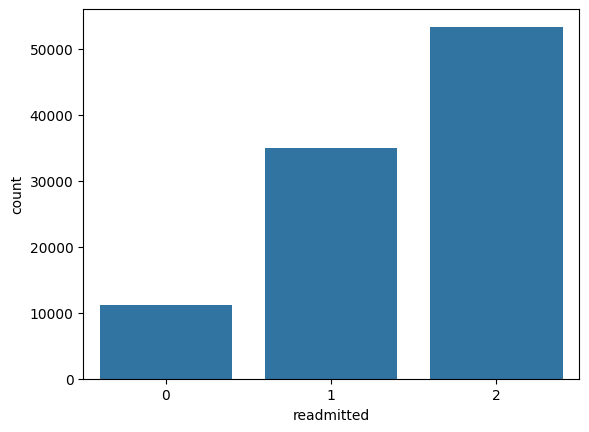

In [ ]:
sns.countplot(x='readmitted', data=df)
plt.show()

# **Visualization**

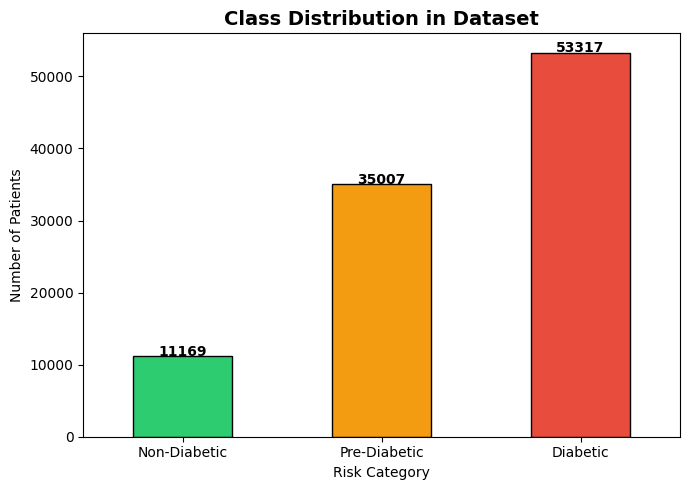

Saved: class_distribution.png


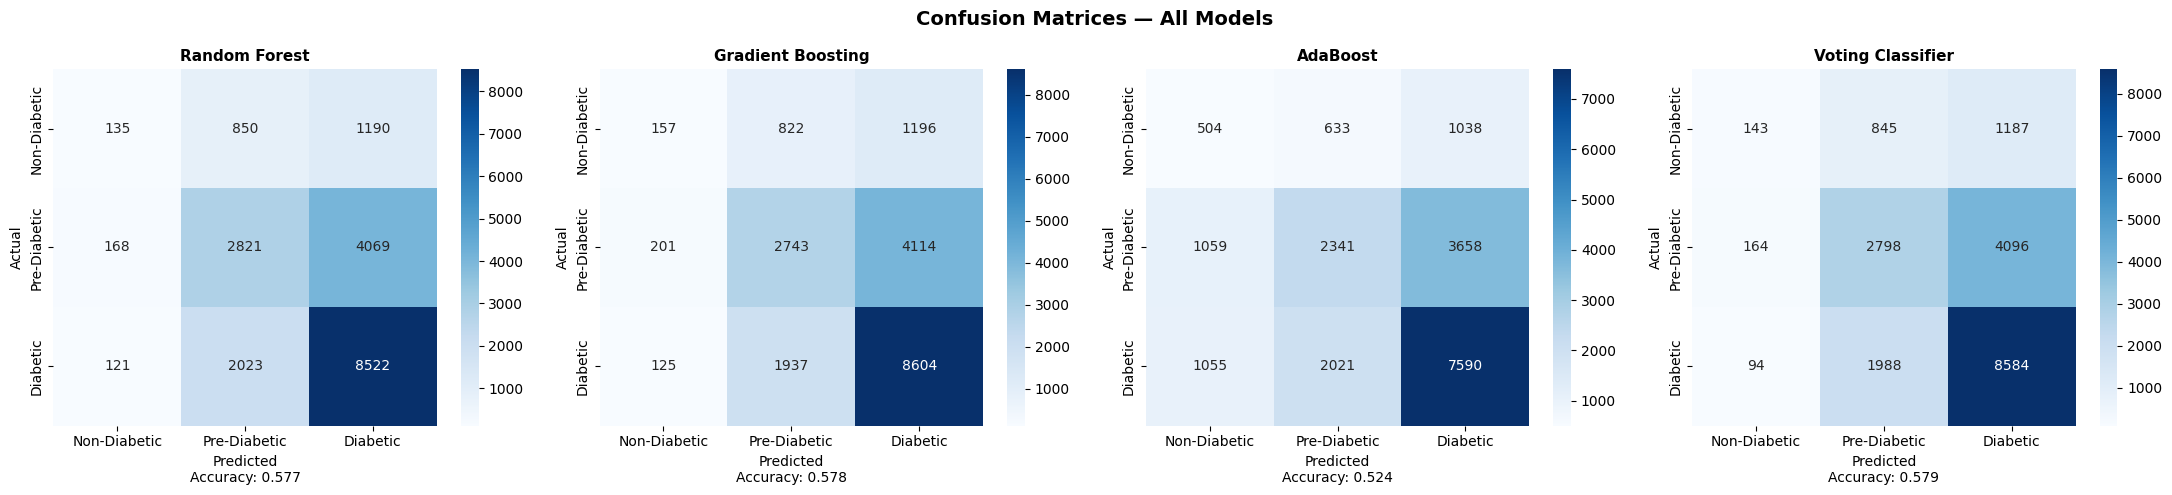

Saved: confusion_matrices.png

 MODEL COMPARISON TABLE
            Model  Accuracy  Precision  Recall  F1-Score
    Random Forest    0.5768     0.5420  0.5768    0.5420
Gradient Boosting    0.5781     0.5438  0.5781    0.5431
         AdaBoost    0.5244     0.5184  0.5244    0.5153
Voting Classifier    0.5792     0.5470  0.5792    0.5437


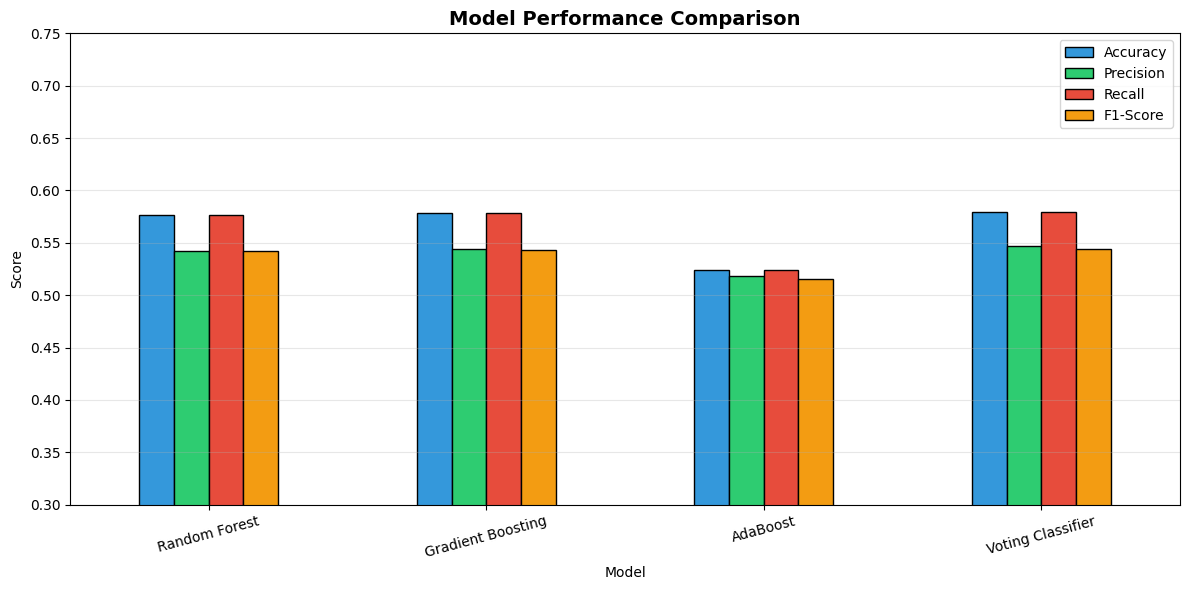

Saved: model_comparison.png


NameError: name 'rf' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

target_names = ['Non-Diabetic', 'Pre-Diabetic', 'Diabetic']

# ── PLOT 1: Class Distribution ────────────────────────────────
plt.figure(figsize=(7, 5))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
y.value_counts().sort_index().plot(
    kind='bar', color=colors, edgecolor='black')
plt.xticks([0, 1, 2], target_names, rotation=0)
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Risk Category')
plt.ylabel('Number of Patients')
for i, v in enumerate(y.value_counts().sort_index()):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

# ── PLOT 2: Confusion Matrices (all 4 models) ─────────────────
predictions = {
    'Random Forest': rf_tuned_pred,
    'Gradient Boosting': gb_pred,
    'AdaBoost': ab_pred,
    'Voting Classifier': vc_soft_pred
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    acc = accuracy_score(y_test, pred)
    ax.set_xlabel(f'Predicted\nAccuracy: {acc:.3f}')
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

# ── PLOT 3: Model Comparison Bar Chart ───────────────────────
results = []
for name, pred in predictions.items():
    results.append({
        'Model': name,
        'Accuracy':  round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_test, pred, average='weighted'), 4),
        'F1-Score':  round(f1_score(y_test, pred, average='weighted'), 4)
    })

results_df = pd.DataFrame(results)
print("\n MODEL COMPARISON TABLE")
print(results_df.to_string(index=False))

# Bar chart
ax = results_df.set_index('Model')[['Accuracy','Precision','Recall','F1-Score']]\
    .plot(kind='bar', figsize=(12, 6),
          color=['#3498db','#2ecc71','#e74c3c','#f39c12'],
          edgecolor='black')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.3, 0.75)
plt.xticks(rotation=15)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

# ── PLOT 4: Feature Importance ────────────────────────────────
# Get original feature names before scaling
import re

# Rebuild feature names from original df
feature_names = df.drop('readmitted', axis=1).columns.tolist()

feat_imp = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)[:15]

plt.figure(figsize=(10, 7))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 15))
feat_imp.sort_values().plot(
    kind='barh', color=colors, edgecolor='black')
plt.title('Top 15 Most Important Features\n(Random Forest)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

# ── PLOT 5: Per-class F1 Score Comparison ─────────────────────
from sklearn.metrics import f1_score

class_f1 = {}
for name, pred in predictions.items():
    scores = f1_score(y_test, pred, average=None, zero_division=0)
    class_f1[name] = scores

class_f1_df = pd.DataFrame(class_f1, index=target_names).T

plt.figure(figsize=(10, 6))
class_f1_df.plot(kind='bar',
                  color=['#2ecc71','#f39c12','#e74c3c'],
                  edgecolor='black',
                  figsize=(11, 6))
plt.title('Per-Class F1 Score by Model', fontsize=13, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=15)
plt.legend(title='Risk Class')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('perclass_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: perclass_f1.png")

# ── PLOT 6: SMOTE Effect ──────────────────────────────────────
# Show before/after SMOTE class counts
before = pd.Series([2175, 7058, 10666], index=target_names)
after_smote = pd.Series([10666, 10666, 10666], index=target_names)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
before.plot(kind='bar', ax=ax1, color=['#2ecc71','#f39c12','#e74c3c'],
            edgecolor='black', title='Before SMOTE')
ax1.set_ylabel('Sample Count')
ax1.set_xticklabels(target_names, rotation=0)

after_smote.plot(kind='bar', ax=ax2, color=['#2ecc71','#f39c12','#e74c3c'],
                  edgecolor='black', title='After SMOTE (Balanced)')
ax2.set_ylabel('Sample Count')
ax2.set_xticklabels(target_names, rotation=0)

plt.suptitle('Class Distribution Before vs After SMOTE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: smote_effect.png")

# Download all plots
from google.colab import files
for fname in ['class_distribution.png', 'confusion_matrices.png',
              'model_comparison.png', 'feature_importance.png',
              'perclass_f1.png', 'smote_effect.png']:
    files.download(fname)

# **second dataset**

Pima Dataset Shape: (768, 9)
Class Distribution:
 Outcome
0    500
1    268
Name: count, dtype: int64

Pima Dataset Results:
            Model      Dataset  Accuracy  F1-Score
    Random Forest Pima Indians    0.7468    0.7491
Gradient Boosting Pima Indians    0.7987    0.8017
         AdaBoost Pima Indians    0.7208    0.7256


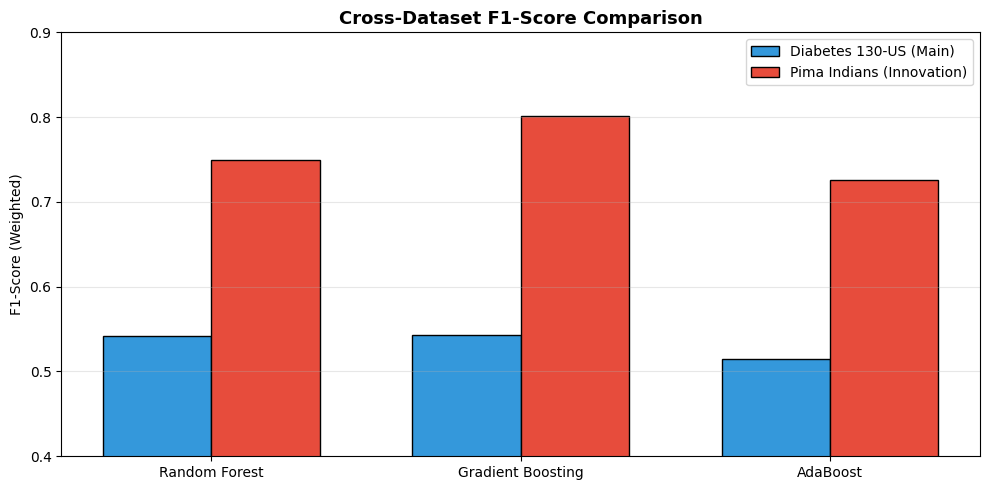

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# INNOVATION — Second Dataset: Pima Indians Diabetes
# ============================================================

pima_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
pima = pd.read_csv(pima_url, header=None,
    names=['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigree','Age','Outcome'])

print("Pima Dataset Shape:", pima.shape)
print("Class Distribution:\n", pima['Outcome'].value_counts())

X_p = pima.drop('Outcome', axis=1)
y_p = pima['Outcome']

X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_p, y_p, test_size=0.2, random_state=42, stratify=y_p)

# Apply SMOTE
from imblearn.over_sampling import SMOTE
X_p_train, y_p_train = SMOTE(random_state=42).fit_resample(
    X_p_train, y_p_train)

# Train same 4 models
pima_results = []
for name, model in [('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
                     ('Gradient Boosting', GradientBoostingClassifier(random_state=42)),
                     ('AdaBoost', AdaBoostClassifier(random_state=42))]:
    model.fit(X_p_train, y_p_train)
    pred = model.predict(X_p_test)
    pima_results.append({
        'Model': name,
        'Dataset': 'Pima Indians',
        'Accuracy': round(accuracy_score(y_p_test, pred), 4),
        'F1-Score': round(f1_score(y_p_test, pred, average='weighted'), 4)
    })

pima_df = pd.DataFrame(pima_results)
print("\nPima Dataset Results:")
print(pima_df.to_string(index=False))

# Cross-dataset comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
width = 0.35

# Main dataset F1
main_f1 = [results_df[results_df['Model']==m]['F1-Score'].values[0]
           for m in ['Random Forest','Gradient Boosting','AdaBoost']]
pima_f1 = pima_df['F1-Score'].tolist()

bars1 = ax.bar(x - width/2, main_f1, width,
               label='Diabetes 130-US (Main)', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, pima_f1, width,
               label='Pima Indians (Innovation)', color='#e74c3c', edgecolor='black')

ax.set_title('Cross-Dataset F1-Score Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score (Weighted)')
ax.set_xticks(x)
ax.set_xticklabels(['Random Forest', 'Gradient Boosting', 'AdaBoost'])
ax.legend()
ax.set_ylim(0.4, 0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cross_dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('cross_dataset_comparison.png')

In [ ]:
import joblib

# Save the ACTUAL MODEL OBJECT not predictions
joblib.dump(vc_soft, 'diabetes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Verify it saved correctly
test_model = joblib.load('diabetes_model.pkl')
print("Model type:", type(test_model))
print("Has predict_proba:", hasattr(test_model, 'predict_proba'))
print("Model saved successfully")

from google.colab import files
files.download('diabetes_model.pkl')
files.download('scaler.pkl')

Model type: <class 'sklearn.ensemble._voting.VotingClassifier'>
Has predict_proba: True
Model saved successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install flask pyngrok joblib -q

from pyngrok import ngrok
ngrok.set_auth_token("3DWkTQbMaHn8fEHJCLFPlyZFI3y_5khWfsZ18EE1ori3iGjLa")
print("Auth token set successfully")

Auth token set successfully


In [ ]:
model = joblib.load('diabetes_model.pkl')
scaler = joblib.load('scaler.pkl')

# Quick sanity check before starting Flask
import numpy as np
test_features = np.array([[5,1,5,3,45,1,15,0,0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1]])
test_scaled = scaler.transform(test_features)
test_pred = model.predict(test_scaled)
test_proba = model.predict_proba(test_scaled)
print("Sanity check passed")
print("Prediction:", test_pred)
print("Probabilities:", test_proba)

Sanity check passed
Prediction: [2]
Probabilities: [[0.23722848 0.31667246 0.44609906]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
from flask import Flask, request, render_template_string
from pyngrok import ngrok
import joblib
import numpy as np
import threading

model  = joblib.load('diabetes_model.pkl')
scaler = joblib.load('scaler.pkl')

app = Flask(__name__)

DEFAULT_FEATURES = [5,1,5,3,45,1,15,0,0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1]

HTML = """
<!DOCTYPE html>
<html>
<head>
<title>Diabetes Risk Predictor</title>
<style>
  * { box-sizing: border-box; margin: 0; padding: 0; }
  body {
    font-family: Arial, sans-serif;
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    min-height: 100vh;
    display: flex; align-items: center;
    justify-content: center; padding: 20px;
  }
  .container {
    background: white; border-radius: 15px;
    padding: 35px; max-width: 650px; width: 100%;
    box-shadow: 0 20px 60px rgba(0,0,0,0.3);
  }
  h1 { color: #2c3e50; text-align: center; margin-bottom: 6px; }
  .subtitle { text-align:center; color:#7f8c8d; margin-bottom:25px; font-size:13px; }
  .grid { display: grid; grid-template-columns: 1fr 1fr; gap: 14px; }
  .form-group { margin-bottom: 14px; }
  label { display:block; font-weight:bold; color:#34495e; margin-bottom:5px; font-size:13px; }
  input, select {
    width:100%; padding:9px 12px;
    border:2px solid #e0e0e0; border-radius:7px; font-size:13px;
  }
  input:focus, select:focus { border-color:#667eea; outline:none; }
  button {
    width:100%; padding:13px;
    background:linear-gradient(135deg,#667eea,#764ba2);
    color:white; border:none; border-radius:8px;
    font-size:15px; font-weight:bold; cursor:pointer; margin-top:8px;
  }

  /* ── Result Card ── */
  .result-card {
    margin-top: 25px;
    border-radius: 12px;
    overflow: hidden;
    box-shadow: 0 4px 20px rgba(0,0,0,0.1);
  }
  .result-header {
    padding: 20px;
    text-align: center;
    font-size: 1.3em;
    font-weight: bold;
    color: white;
  }
  .header-0 { background: linear-gradient(135deg, #27ae60, #2ecc71); }
  .header-1 { background: linear-gradient(135deg, #e67e22, #f39c12); }
  .header-2 { background: linear-gradient(135deg, #c0392b, #e74c3c); }

  .result-body { padding: 20px; background: #fafafa; }

  /* ── Probability Bars ── */
  .prob-section { margin-bottom: 18px; }
  .prob-section h4 { color: #2c3e50; margin-bottom: 12px; font-size: 14px; }
  .prob-row { margin-bottom: 10px; }
  .prob-label {
    display: flex; justify-content: space-between;
    font-size: 13px; color: #555; margin-bottom: 4px;
  }
  .prob-bar-bg {
    background: #e0e0e0; border-radius: 20px; height: 14px; overflow: hidden;
  }
  .prob-bar-fill {
    height: 100%; border-radius: 20px;
    transition: width 1s ease;
  }
  .bar-0 { background: linear-gradient(90deg, #27ae60, #2ecc71); }
  .bar-1 { background: linear-gradient(90deg, #e67e22, #f39c12); }
  .bar-2 { background: linear-gradient(90deg, #c0392b, #e74c3c); }

  /* ── Stats Grid ── */
  .stats-grid {
    display: grid; grid-template-columns: repeat(3, 1fr);
    gap: 10px; margin-bottom: 18px;
  }
  .stat-box {
    background: white; border-radius: 8px; padding: 12px;
    text-align: center; border: 1px solid #e0e0e0;
    box-shadow: 0 2px 6px rgba(0,0,0,0.05);
  }
  .stat-value { font-size: 1.4em; font-weight: bold; color: #2c3e50; }
  .stat-label { font-size: 11px; color: #7f8c8d; margin-top: 3px; }

  /* ── Recommendation ── */
  .recommendation {
    padding: 14px; border-radius: 8px;
    font-size: 13px; line-height: 1.7; color: #444;
    border-left: 4px solid #667eea;
    background: #f0f4ff;
  }
  .recommendation strong { color: #2c3e50; }

  .footer { text-align:center; margin-top:18px; font-size:11px; color:#aaa; }
</style>
</head>
<body>
<div class="container">
  <h1>🏥 Diabetes Risk Assessment</h1>
  <p class="subtitle">Smart Healthcare Prediction System — LGU CSE6505 Machine Learning</p>

  <form method="POST">
    <div class="grid">
      <div class="form-group">
        <label>Age Group</label>
        <select name="age">
          <option value="2">[20-30)</option>
          <option value="3">[30-40)</option>
          <option value="4" selected>[40-50)</option>
          <option value="5">[50-60)</option>
          <option value="6">[60-70)</option>
          <option value="7">[70-80)</option>
          <option value="8">[80-90)</option>
        </select>
      </div>
      <div class="form-group">
        <label>Gender</label>
        <select name="gender">
          <option value="0">Female</option>
          <option value="1">Male</option>
        </select>
      </div>
      <div class="form-group">
        <label>Time in Hospital (days)</label>
        <input type="number" name="time_in_hospital" value="4" min="1" max="14">
      </div>
      <div class="form-group">
        <label>Number of Lab Procedures</label>
        <input type="number" name="num_lab_procedures" value="45" min="1" max="132">
      </div>
      <div class="form-group">
        <label>Number of Procedures</label>
        <input type="number" name="num_procedures" value="1" min="0" max="6">
      </div>
      <div class="form-group">
        <label>Number of Medications</label>
        <input type="number" name="num_medications" value="15" min="1" max="81">
      </div>
      <div class="form-group">
        <label>Number of Outpatient Visits</label>
        <input type="number" name="number_outpatient" value="0" min="0" max="42">
      </div>
      <div class="form-group">
        <label>Number of Diagnoses</label>
        <input type="number" name="number_diagnoses" value="7" min="1" max="16">
      </div>
    </div>
    <div class="form-group">
      <label>Insulin Usage</label>
      <select name="insulin">
        <option value="0">No</option>
        <option value="1">Steady</option>
        <option value="2">Up</option>
        <option value="3">Down</option>
      </select>
    </div>
    <button type="submit">🔍 Predict Diabetes Risk</button>
  </form>

  {% if prediction is not none %}
  <div class="result-card">

    <!-- Header -->
    <div class="result-header header-{{ prediction }}">
      {% if prediction == 0 %} ✅ LOW RISK — Non-Diabetic
      {% elif prediction == 1 %} ⚠️ MODERATE RISK — Pre-Diabetic
      {% else %} 🔴 HIGH RISK — Diabetic (Readmission Likely) {% endif %}
    </div>

    <div class="result-body">

      <!-- Stats -->
      <div class="stats-grid">
        <div class="stat-box">
          <div class="stat-value" style="color:
            {% if prediction==0 %}#27ae60
            {% elif prediction==1 %}#e67e22
            {% else %}#c0392b{% endif %}">
            {% if prediction==0 %}Low
            {% elif prediction==1 %}Medium
            {% else %}High{% endif %}
          </div>
          <div class="stat-label">Risk Level</div>
        </div>
        <div class="stat-box">
          <div class="stat-value">{{ confidence }}%</div>
          <div class="stat-label">Confidence</div>
        </div>
        <div class="stat-box">
          <div class="stat-value">{{ model_name }}</div>
          <div class="stat-label">Algorithm</div>
        </div>
      </div>

      <!-- Probability Bars -->
      <div class="prob-section">
        <h4>📊 Risk Probability Breakdown</h4>
        <div class="prob-row">
          <div class="prob-label">
            <span>✅ Non-Diabetic</span>
            <span>{{ probs[0] }}%</span>
          </div>
          <div class="prob-bar-bg">
            <div class="prob-bar-fill bar-0" style="width:{{ probs[0] }}%"></div>
          </div>
        </div>
        <div class="prob-row">
          <div class="prob-label">
            <span>⚠️ Pre-Diabetic</span>
            <span>{{ probs[1] }}%</span>
          </div>
          <div class="prob-bar-bg">
            <div class="prob-bar-fill bar-1" style="width:{{ probs[1] }}%"></div>
          </div>
        </div>
        <div class="prob-row">
          <div class="prob-label">
            <span>🔴 Diabetic</span>
            <span>{{ probs[2] }}%</span>
          </div>
          <div class="prob-bar-bg">
            <div class="prob-bar-fill bar-2" style="width:{{ probs[2] }}%"></div>
          </div>
        </div>
      </div>

      <!-- Recommendation -->
      <div class="recommendation">
        <strong>📋 Health Recommendation:</strong><br>
        {% if prediction == 0 %}
          Maintain a healthy lifestyle with balanced diet and regular exercise.
          Annual blood glucose checkups are advised. Current indicators
          suggest no immediate risk of diabetes readmission.
        {% elif prediction == 1 %}
          Blood glucose levels require monitoring. Consult a physician
          within 30 days. Consider dietary modifications, reduce sugar intake,
          and increase physical activity. Follow-up diagnostic tests recommended.
        {% else %}
          Immediate medical consultation is strongly recommended.
          High readmission risk detected based on clinical indicators.
          Strict medication adherence, daily glucose monitoring, and
          specialist referral are essential. Do not delay treatment.
        {% endif %}
      </div>

    </div>
  </div>
  {% endif %}

  <p class="footer">Smart Healthcare Prediction System | CSE6505 Machine Learning | LGU</p>
</div>
</body>
</html>
"""

@app.route('/', methods=['GET', 'POST'])
def index():
    prediction = None
    confidence = None
    probs = None
    model_name = "Voting Classifier"

    if request.method == 'POST':
        try:
            features = DEFAULT_FEATURES.copy()
            features[1]  = int(request.form['gender'])
            features[2]  = int(request.form['age'])
            features[3]  = int(request.form['time_in_hospital'])
            features[4]  = int(request.form['num_lab_procedures'])
            features[5]  = int(request.form['num_procedures'])
            features[6]  = int(request.form['num_medications'])
            features[7]  = int(request.form['number_outpatient'])
            features[10] = int(request.form['number_diagnoses'])
            features[28] = int(request.form['insulin'])

            features_array  = np.array([features])
            features_scaled = scaler.transform(features_array)

            prediction  = int(model.predict(features_scaled)[0])

            # Get probabilities for the bars
            raw_probs   = model.predict_proba(features_scaled)[0]
            probs       = [round(p * 100, 1) for p in raw_probs]
            confidence  = max(probs)

            print(f"Prediction: {prediction}, Probs: {probs}")

        except Exception as e:
            print("ERROR:", e)
            import traceback
            traceback.print_exc()
            prediction = None

    return render_template_string(HTML,
        prediction=prediction,
        confidence=confidence,
        probs=probs,
        model_name=model_name)

# Kill any existing Flask/ngrok before restarting
import os
os.system("pkill -f 'flask'")

from pyngrok import ngrok as ng
ng.kill()

def run_app():
    app.run(port=5000, use_reloader=False, debug=False)

thread = threading.Thread(target=run_app)
thread.daemon = True
thread.start()

import time
time.sleep(2)

public_url = ng.connect(5000)
print("=" * 55)
print(f"  LIVE URL: {public_url}")
print("=" * 55)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


  LIVE URL: NgrokTunnel: "https://tattling-paramedic-overcook.ngrok-free.dev" -> "http://localhost:5000"


In [ ]:
# Check how many features your model expects
print("Features model was trained on:", X_train.shape[1])

Features model was trained on: 39


In [ ]:
# DIAGNOSTIC — run this first to see exact error
try:
    features = DEFAULT_FEATURES.copy()
    features_array = np.array([features])
    features_scaled = scaler.transform(features_array)

    pred = model.predict(features_scaled)
    print("Prediction works:", pred)

    proba = model.predict_proba(features_scaled)
    print("Proba works:", proba)

except Exception as e:
    print("ERROR:", e)

ERROR: 'numpy.ndarray' object has no attribute 'predict'


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
